WORKFLOW :  X=normalize(255.0),y= One-hot encoding -> split data -> reshape ->Model define -> compile -> train -> Evaluate(Test accuracy: 0.7565)

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gauravneupane/flavia-dataset")

print("Path to dataset files:", path)

100%|██████████| 932M/932M [00:39<00:00, 24.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gauravneupane/flavia-dataset/versions/1


In [9]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os

Updated dataset path: /root/.cache/kagglehub/datasets/gauravneupane/flavia-dataset/versions/1/Leaves
Leaves folder contains: ['3494.jpg', '3097.jpg', '3550.jpg', '2561.jpg', '3593.jpg', '3437.jpg', '2078.jpg', '2384.jpg', '3532.jpg', '1239.jpg', '2471.jpg', '1509.jpg', '2088.jpg', '2550.jpg', '2229.jpg', '2045.jpg', '1132.jpg', '3296.jpg', '2197.jpg', '2598.jpg', '3292.jpg', '3229.jpg', '3280.jpg', '1172.jpg', '2059.jpg', '3293.jpg', '1368.jpg', '2444.jpg', '2597.jpg', '3233.jpg', '3572.jpg', '3403.jpg', '3095.jpg', '3242.jpg', '1230.jpg', '1323.jpg', '2540.jpg', '2277.jpg', '1529.jpg', '1465.jpg', '2350.jpg', '2104.jpg', '1446.jpg', '3451.jpg', '2578.jpg', '3221.jpg', '2539.jpg', '2449.jpg', '3359.jpg', '3220.jpg', '2247.jpg', '2072.jpg', '3059.jpg', '3091.jpg', '2671.jpg', '3004.jpg', '1545.jpg', '2255.jpg', '1025.jpg', '2481.jpg', '2182.jpg', '1538.jpg', '1588.jpg', '2116.jpg', '2381.jpg', '1567.jpg', '2128.jpg', '2499.jpg', '1559.jpg', '1602.jpg', '3224.jpg', '3372.jpg', '2564.jpg'

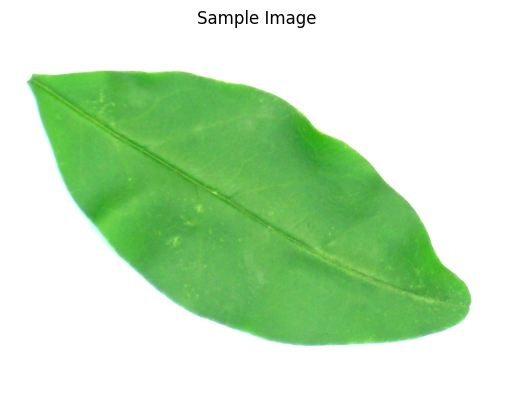

In [5]:
dataset_path = os.path.join(path, "Leaves")  # "Leaves" folder ko include karein
print("Updated dataset path:", dataset_path)
all_files = os.listdir(dataset_path)
# Check what is inside "Leaves"
print("Leaves folder contains:", os.listdir(dataset_path))

import cv2
image_path = os.path.join(dataset_path, all_files[1])  # First image ka path

# Read and display image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB

plt.imshow(img)
plt.title("Sample Image")
plt.axis("off")
plt.show()


In [6]:
img.shape

(1200, 1600, 3)

In [7]:
total_images = len(all_files)
print("Total images in dataset:", total_images)

Total images in dataset: 1908


In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

csv_file = os.path.join(dataset_path, "all.csv")

# Load CSV file
df = pd.read_csv(csv_file)

# Image and label lists
images = []
labels = []

# Load images
for index, row in df.iterrows():
    img_path = os.path.join(dataset_path, row['id'])
    img = cv2.imread(img_path)  # Load image
    img = cv2.resize(img, (128, 128))  # Resize to 128x128
    images.append(img)
    labels.append(row['y'])

# Convert to NumPy arrays
X = np.array(images, dtype="float32") / 255.0  # Normalize images
y = np.array(labels)

# One-hot encoding for labels
num_classes = len(set(y))  # Unique class count
y = to_categorical(y, num_classes)

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print dataset shapes
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (1525, 128, 128, 3) (1525, 32)
Test shape: (382, 128, 128, 3) (382, 32)


In [13]:
print(X_train[0])  # Pehli image ka array output karega

[[[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 ...

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]
  ...
  [1. 1. 1.]
  [1. 1. 1.]
  [1. 1. 1.]]]


In [14]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
print("New shape:", X_train_flat.shape, X_test_flat.shape)

New shape: (1525, 49152) (382, 49152)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# ANN Model
model = Sequential([
    Dense(256, activation='relu', input_shape=(49152,)),  # Input Layer
    Dense(128, activation='relu'),  # Hidden Layer
    Dense(num_classes, activation='softmax')  # Output Layer
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
history = model.fit(X_train_flat, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_test_flat, y_test))

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 254ms/step - accuracy: 0.7505 - loss: 0.7399 - val_accuracy: 0.6885 - val_loss: 1.0616
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 241ms/step - accuracy: 0.7462 - loss: 0.7457 - val_accuracy: 0.7199 - val_loss: 0.9892
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 251ms/step - accuracy: 0.7276 - loss: 0.8689 - val_accuracy: 0.7016 - val_loss: 0.9876
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 269ms/step - accuracy: 0.7836 - loss: 0.6434 - val_accuracy: 0.7225 - val_loss: 0.9253
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 19s 242ms/step - accuracy: 0.8049 - loss: 0.6187 - val_accuracy: 0.7356 - val_loss: 0.9151
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - accuracy: 0.7682 - loss: 0.7212 - val_accuracy: 0.6492 - val_loss: 1.2025
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.7395 - loss: 0.7847 - val_accuracy: 0.7618 - val_loss: 0.8660
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 238ms/step - accuracy: 0.7620 - loss: 0.7246 - val_accu

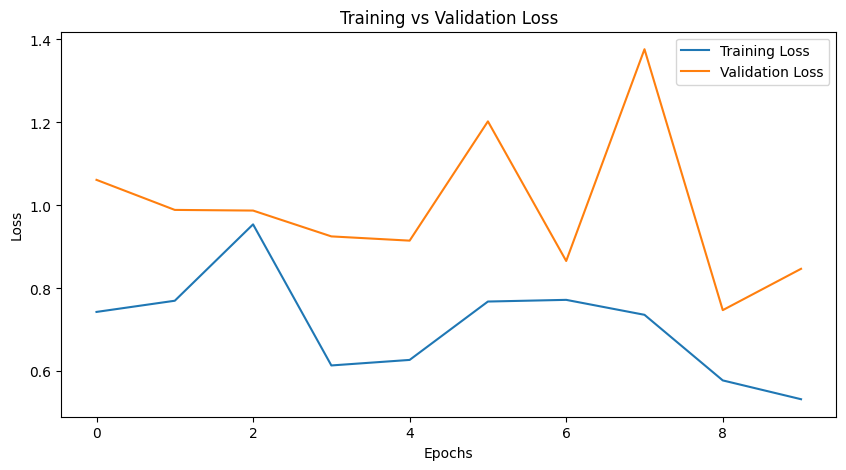

In [20]:
# Plot Training & Validation Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [22]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test_flat, y_test)
print(f"Test accuracy: {test_acc:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7778 - loss: 0.7445
Test accuracy: 0.7565


In [23]:
predictions = model.predict(X_test_flat)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step


In [25]:
# Display an example
def plot_image(index):
    plt.imshow(X_test_flat[index].reshape(128, 128, 3))  # 128x128x3 shape me reshape
    plt.title(f"Predicted: {np.argmax(predictions[index])}, Actual: {np.argmax(y_test[index])}")
    plt.axis('off')
    plt.show()

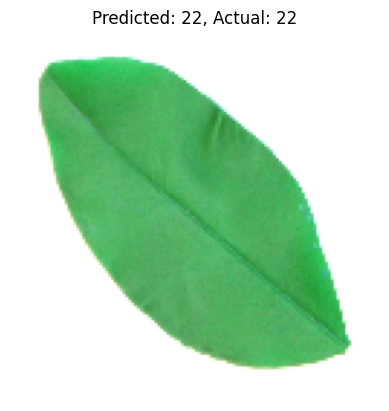

In [32]:
plot_image(5)